# Resultados

Comenzamos cargando las librerías necesarias y cargando el rendimiendo de los modelos de aprendizaje.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Cargar resultados
results_path = 'resultados_eval/evaluacion_resultados.csv'
if not os.path.exists(results_path):
    print(f"Error: No se encuentra el archivo {results_path}. Ejecuta primero eval.ipynb.")
else:
    df = pd.read_csv(results_path)
    print("Datos cargados correctamente.")
    display(df.head())

Datos cargados correctamente.


,Dataset,Model,Fold,Fm,Acc,S,SP,RC,PR,FNR,FPR,spatial_acc,AUC
0,original,KNN,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.0
1,original,SVM,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.0
2,original,NaiveBayes,1,0.966583,0.977778,0.966667,0.983333,0.966667,0.969697,0.033333,0.016667,0.936364,1.0
3,original,RandomForest,1,0.966583,0.977778,0.966667,0.983333,0.966667,0.969697,0.033333,0.016667,0.936364,1.0
4,original,Ensemble_Votacion,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.0


## Generación de Tablas Resumen (Media $\pm$ Desviación Típica)

Generamos unas tablas con un resumen de los datos obtenidos en la evaluación de los modelos que contiene la media y la desviación de cada método en cada dataset para cada estadística.

In [4]:
# Definimos las métricas
metrics = ['Fm', 'Acc', 'S', 'SP', 'RC', 'PR', 'FNR', 'FPR', 'AUC']

# Calculamos las medias y desviaciones
grouped = df.groupby(['Dataset', 'Model'])[metrics]
means = grouped.mean()
stds = grouped.std()

# Combinamos los dataframes anteriores
summary_df = means.round(4).astype(str) + " ± " + stds.round(4).astype(str)

# Para que se vea mejor, reseteamos el índice
summary_df.reset_index(inplace=True)

display(summary_df)

,Dataset,Model,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
0,estandarizadoPCA80,Ensemble_Media,0.8994 ± 0.0709,0.9333 ± 0.0471,0.9 ± 0.0707,0.95 ± 0.0354,0.9 ± 0.0707,0.9053 ± 0.0706,0.1 ± 0.0707,0.05 ± 0.0354,0.977 ± 0.0221
1,estandarizadoPCA80,Ensemble_Mediana,0.9059 ± 0.0645,0.9378 ± 0.0427,0.9067 ± 0.0641,0.9533 ± 0.0321,0.9067 ± 0.0641,0.9133 ± 0.0625,0.0933 ± 0.0641,0.0467 ± 0.0321,0.9767 ± 0.0204
2,estandarizadoPCA80,Ensemble_Votacion,0.8995 ± 0.0745,0.9333 ± 0.0497,0.9 ± 0.0745,0.95 ± 0.0373,0.9 ± 0.0745,0.9046 ± 0.0752,0.1 ± 0.0745,0.05 ± 0.0373,0.977 ± 0.0221
3,estandarizadoPCA80,KNN,0.9197 ± 0.0607,0.9467 ± 0.0404,0.92 ± 0.0606,0.96 ± 0.0303,0.92 ± 0.0606,0.923 ± 0.0605,0.08 ± 0.0606,0.04 ± 0.0303,0.9628 ± 0.0384
4,estandarizadoPCA80,NaiveBayes,0.8927 ± 0.0762,0.9289 ± 0.0507,0.8933 ± 0.076,0.9467 ± 0.038,0.8933 ± 0.076,0.8992 ± 0.0775,0.1067 ± 0.076,0.0533 ± 0.038,0.9773 ± 0.0228
...,...,...,...,...,...,...,...,...,...,...,...
58,originalPCA95,Ensemble_Votacion,0.9531 ± 0.0382,0.9689 ± 0.0253,0.9533 ± 0.038,0.9767 ± 0.019,0.9533 ± 0.038,0.9572 ± 0.0365,0.0467 ± 0.038,0.0233 ± 0.019,0.9917 ± 0.0082
59,originalPCA95,KNN,0.9665 ± 0.0238,0.9778 ± 0.0157,0.9667 ± 0.0236,0.9833 ± 0.0118,0.9667 ± 0.0236,0.9707 ± 0.0197,0.0333 ± 0.0236,0.0167 ± 0.0118,0.981 ± 0.0235
60,originalPCA95,NaiveBayes,0.8995 ± 0.0623,0.9333 ± 0.0416,0.9 ± 0.0624,0.95 ± 0.0312,0.9 ± 0.0624,0.9057 ± 0.0639,0.1 ± 0.0624,0.05 ± 0.0312,0.9787 ± 0.0195
61,originalPCA95,RandomForest,0.9597 ± 0.0282,0.9733 ± 0.0186,0.96 ± 0.0279,0.98 ± 0.0139,0.96 ± 0.0279,0.9657 ± 0.023,0.04 ± 0.0279,0.02 ± 0.0139,0.9888 ± 0.0162


### Tablas por Método

Mostramos una tabla para cada uno de los métodos usados que contiene todas las métricas para cada dataset.

In [5]:
# Cogemos todos los métodos únicos
methods = summary_df['Model'].unique()

# Mostramos una tabla para cada método
for method in methods:
    print(f"\n--- Tabla Resumen para: {method} ---")
    method_df = summary_df[summary_df['Model'] == method].set_index('Dataset')
    display(method_df[metrics])


--- Tabla Resumen para: Ensemble_Media ---


,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
Dataset,,,,,,,,,
estandarizadoPCA80,0.8994 ± 0.0709,0.9333 ± 0.0471,0.9 ± 0.0707,0.95 ± 0.0354,0.9 ± 0.0707,0.9053 ± 0.0706,0.1 ± 0.0707,0.05 ± 0.0354,0.977 ± 0.0221
estandarizadoPCA95,0.8994 ± 0.0709,0.9333 ± 0.0471,0.9 ± 0.0707,0.95 ± 0.0354,0.9 ± 0.0707,0.9053 ± 0.0706,0.1 ± 0.0707,0.05 ± 0.0354,0.977 ± 0.0221
estandarizados,0.9599 ± 0.0435,0.9733 ± 0.029,0.96 ± 0.0435,0.98 ± 0.0217,0.96 ± 0.0435,0.9611 ± 0.0428,0.04 ± 0.0435,0.02 ± 0.0217,0.9953 ± 0.0056
normalizadoPCA80,0.9532 ± 0.0381,0.9689 ± 0.0253,0.9533 ± 0.038,0.9767 ± 0.019,0.9533 ± 0.038,0.955 ± 0.0377,0.0467 ± 0.038,0.0233 ± 0.019,0.9933 ± 0.0078
normalizadoPCA95,0.9465 ± 0.0448,0.9644 ± 0.0298,0.9467 ± 0.0447,0.9733 ± 0.0224,0.9467 ± 0.0447,0.9488 ± 0.0442,0.0533 ± 0.0447,0.0267 ± 0.0224,0.992 ± 0.0102
normalizados,0.9532 ± 0.0507,0.9689 ± 0.0337,0.9533 ± 0.0506,0.9767 ± 0.0253,0.9533 ± 0.0506,0.9549 ± 0.0495,0.0467 ± 0.0506,0.0233 ± 0.0253,0.9973 ± 0.0037
original,0.9665 ± 0.0335,0.9778 ± 0.0222,0.9667 ± 0.0333,0.9833 ± 0.0167,0.9667 ± 0.0333,0.9695 ± 0.0308,0.0333 ± 0.0333,0.0167 ± 0.0167,0.9953 ± 0.0051
originalPCA80,0.9262 ± 0.0499,0.9511 ± 0.033,0.9267 ± 0.0494,0.9633 ± 0.0247,0.9267 ± 0.0494,0.931 ± 0.0472,0.0733 ± 0.0494,0.0367 ± 0.0247,0.988 ± 0.0102
originalPCA95,0.9665 ± 0.0238,0.9778 ± 0.0157,0.9667 ± 0.0236,0.9833 ± 0.0118,0.9667 ± 0.0236,0.9707 ± 0.0197,0.0333 ± 0.0236,0.0167 ± 0.0118,0.9917 ± 0.0082



--- Tabla Resumen para: Ensemble_Mediana ---


,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
Dataset,,,,,,,,,
estandarizadoPCA80,0.9059 ± 0.0645,0.9378 ± 0.0427,0.9067 ± 0.0641,0.9533 ± 0.0321,0.9067 ± 0.0641,0.9133 ± 0.0625,0.0933 ± 0.0641,0.0467 ± 0.0321,0.9767 ± 0.0204
estandarizadoPCA95,0.9059 ± 0.0645,0.9378 ± 0.0427,0.9067 ± 0.0641,0.9533 ± 0.0321,0.9067 ± 0.0641,0.9133 ± 0.0625,0.0933 ± 0.0641,0.0467 ± 0.0321,0.9767 ± 0.0204
estandarizados,0.9532 ± 0.0507,0.9689 ± 0.0337,0.9533 ± 0.0506,0.9767 ± 0.0253,0.9533 ± 0.0506,0.9549 ± 0.0495,0.0467 ± 0.0506,0.0233 ± 0.0253,0.9947 ± 0.0069
normalizadoPCA80,0.96 ± 0.0279,0.9733 ± 0.0186,0.96 ± 0.0279,0.98 ± 0.0139,0.96 ± 0.0279,0.9612 ± 0.0283,0.04 ± 0.0279,0.02 ± 0.0139,0.9933 ± 0.0078
normalizadoPCA95,0.9465 ± 0.0448,0.9644 ± 0.0298,0.9467 ± 0.0447,0.9733 ± 0.0224,0.9467 ± 0.0447,0.9488 ± 0.0442,0.0533 ± 0.0447,0.0267 ± 0.0224,0.9913 ± 0.0107
normalizados,0.9532 ± 0.0507,0.9689 ± 0.0337,0.9533 ± 0.0506,0.9767 ± 0.0253,0.9533 ± 0.0506,0.9549 ± 0.0495,0.0467 ± 0.0506,0.0233 ± 0.0253,0.9967 ± 0.0033
original,0.9599 ± 0.0435,0.9733 ± 0.029,0.96 ± 0.0435,0.98 ± 0.0217,0.96 ± 0.0435,0.9611 ± 0.0428,0.04 ± 0.0435,0.02 ± 0.0217,0.995 ± 0.0055
originalPCA80,0.9327 ± 0.0414,0.9556 ± 0.0272,0.9333 ± 0.0408,0.9667 ± 0.0204,0.9333 ± 0.0408,0.9406 ± 0.0366,0.0667 ± 0.0408,0.0333 ± 0.0204,0.988 ± 0.0102
originalPCA95,0.9665 ± 0.0238,0.9778 ± 0.0157,0.9667 ± 0.0236,0.9833 ± 0.0118,0.9667 ± 0.0236,0.9707 ± 0.0197,0.0333 ± 0.0236,0.0167 ± 0.0118,0.991 ± 0.0098



--- Tabla Resumen para: Ensemble_Votacion ---


...

,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
Dataset,,,,,,,,,
estandarizadoPCA80,0.8927 ± 0.0762,0.9289 ± 0.0507,0.8933 ± 0.076,0.9467 ± 0.038,0.8933 ± 0.076,0.8992 ± 0.0775,0.1067 ± 0.076,0.0533 ± 0.038,0.9773 ± 0.0228
estandarizadoPCA95,0.8927 ± 0.0762,0.9289 ± 0.0507,0.8933 ± 0.076,0.9467 ± 0.038,0.8933 ± 0.076,0.8992 ± 0.0775,0.1067 ± 0.076,0.0533 ± 0.038,0.9773 ± 0.0228
estandarizados,0.9465 ± 0.0448,0.9644 ± 0.0298,0.9467 ± 0.0447,0.9733 ± 0.0224,0.9467 ± 0.0447,0.9488 ± 0.0442,0.0533 ± 0.0447,0.0267 ± 0.0224,0.9933 ± 0.0078
normalizadoPCA80,0.9532 ± 0.0299,0.9689 ± 0.0199,0.9533 ± 0.0298,0.9767 ± 0.0149,0.9533 ± 0.0298,0.9562 ± 0.0287,0.0467 ± 0.0298,0.0233 ± 0.0149,0.9933 ± 0.0078
normalizadoPCA95,0.9261 ± 0.0645,0.9511 ± 0.0427,0.9267 ± 0.0641,0.9633 ± 0.0321,0.9267 ± 0.0641,0.9322 ± 0.0623,0.0733 ± 0.0641,0.0367 ± 0.0321,0.984 ± 0.0172
normalizados,0.9465 ± 0.0448,0.9644 ± 0.0298,0.9467 ± 0.0447,0.9733 ± 0.0224,0.9467 ± 0.0447,0.9488 ± 0.0442,0.0533 ± 0.0447,0.0267 ± 0.0224,0.9933 ± 0.0078
original,0.9465 ± 0.0448,0.9644 ± 0.0298,0.9467 ± 0.0447,0.9733 ± 0.0224,0.9467 ± 0.0447,0.9488 ± 0.0442,0.0533 ± 0.0447,0.0267 ± 0.0224,0.9933 ± 0.0078
originalPCA80,0.9328 ± 0.0476,0.9556 ± 0.0314,0.9333 ± 0.0471,0.9667 ± 0.0236,0.9333 ± 0.0471,0.9394 ± 0.0445,0.0667 ± 0.0471,0.0333 ± 0.0236,0.99 ± 0.0078
originalPCA95,0.8995 ± 0.0623,0.9333 ± 0.0416,0.9 ± 0.0624,0.95 ± 0.0312,0.9 ± 0.0624,0.9057 ± 0.0639,0.1 ± 0.0624,0.05 ± 0.0312,0.9787 ± 0.0195



--- Tabla Resumen para: RandomForest ---


,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
Dataset,,,,,,,,,
estandarizadoPCA80,0.8798 ± 0.0962,0.92 ± 0.064,0.88 ± 0.096,0.94 ± 0.048,0.88 ± 0.096,0.8807 ± 0.0959,0.12 ± 0.096,0.06 ± 0.048,0.9678 ± 0.0345
estandarizadoPCA95,0.8798 ± 0.0962,0.92 ± 0.064,0.88 ± 0.096,0.94 ± 0.048,0.88 ± 0.096,0.8807 ± 0.0959,0.12 ± 0.096,0.06 ± 0.048,0.9678 ± 0.0345
estandarizados,0.9464 ± 0.0299,0.9644 ± 0.0199,0.9467 ± 0.0298,0.9733 ± 0.0149,0.9467 ± 0.0298,0.9512 ± 0.0294,0.0533 ± 0.0298,0.0267 ± 0.0149,0.9943 ± 0.0083
normalizadoPCA80,0.9263 ± 0.0279,0.9511 ± 0.0186,0.9267 ± 0.0279,0.9633 ± 0.0139,0.9267 ± 0.0279,0.9327 ± 0.0295,0.0733 ± 0.0279,0.0367 ± 0.0139,0.9837 ± 0.0119
normalizadoPCA95,0.9462 ± 0.0511,0.9644 ± 0.0337,0.9467 ± 0.0506,0.9733 ± 0.0253,0.9467 ± 0.0506,0.9518 ± 0.0472,0.0533 ± 0.0506,0.0267 ± 0.0253,0.9895 ± 0.0142
normalizados,0.9464 ± 0.0299,0.9644 ± 0.0199,0.9467 ± 0.0298,0.9733 ± 0.0149,0.9467 ± 0.0298,0.9512 ± 0.0294,0.0533 ± 0.0298,0.0267 ± 0.0149,0.9945 ± 0.008
original,0.9464 ± 0.0299,0.9644 ± 0.0199,0.9467 ± 0.0298,0.9733 ± 0.0149,0.9467 ± 0.0298,0.9512 ± 0.0294,0.0533 ± 0.0298,0.0267 ± 0.0149,0.9943 ± 0.0083
originalPCA80,0.9061 ± 0.0598,0.9378 ± 0.0398,0.9067 ± 0.0596,0.9533 ± 0.0298,0.9067 ± 0.0596,0.9128 ± 0.0607,0.0933 ± 0.0596,0.0467 ± 0.0298,0.981 ± 0.0188
originalPCA95,0.9597 ± 0.0282,0.9733 ± 0.0186,0.96 ± 0.0279,0.98 ± 0.0139,0.96 ± 0.0279,0.9657 ± 0.023,0.04 ± 0.0279,0.02 ± 0.0139,0.9888 ± 0.0162



--- Tabla Resumen para: SVM ---


,Fm,Acc,S,SP,RC,PR,FNR,FPR,AUC
Dataset,,,,,,,,,
estandarizadoPCA80,0.906 ± 0.0553,0.9378 ± 0.0365,0.9067 ± 0.0548,0.9533 ± 0.0274,0.9067 ± 0.0548,0.9109 ± 0.0516,0.0933 ± 0.0548,0.0467 ± 0.0274,0.9823 ± 0.0155
estandarizadoPCA95,0.906 ± 0.0553,0.9378 ± 0.0365,0.9067 ± 0.0548,0.9533 ± 0.0274,0.9067 ± 0.0548,0.9109 ± 0.0516,0.0933 ± 0.0548,0.0467 ± 0.0274,0.9823 ± 0.0155
estandarizados,0.9532 ± 0.0507,0.9689 ± 0.0337,0.9533 ± 0.0506,0.9767 ± 0.0253,0.9533 ± 0.0506,0.9549 ± 0.0495,0.0467 ± 0.0506,0.0233 ± 0.0253,0.9957 ± 0.0053
normalizadoPCA80,0.9532 ± 0.0381,0.9689 ± 0.0253,0.9533 ± 0.038,0.9767 ± 0.019,0.9533 ± 0.038,0.955 ± 0.0377,0.0467 ± 0.038,0.0233 ± 0.019,0.9933 ± 0.0078
normalizadoPCA95,0.9532 ± 0.0381,0.9689 ± 0.0253,0.9533 ± 0.038,0.9767 ± 0.019,0.9533 ± 0.038,0.955 ± 0.0377,0.0467 ± 0.038,0.0233 ± 0.019,0.9947 ± 0.0056
normalizados,0.9532 ± 0.0507,0.9689 ± 0.0337,0.9533 ± 0.0506,0.9767 ± 0.0253,0.9533 ± 0.0506,0.9549 ± 0.0495,0.0467 ± 0.0506,0.0233 ± 0.0253,0.9973 ± 0.0037
original,0.9665 ± 0.0335,0.9778 ± 0.0222,0.9667 ± 0.0333,0.9833 ± 0.0167,0.9667 ± 0.0333,0.9695 ± 0.0308,0.0333 ± 0.0333,0.0167 ± 0.0167,0.9967 ± 0.0058
originalPCA80,0.9261 ± 0.0439,0.9511 ± 0.029,0.9267 ± 0.0435,0.9633 ± 0.0217,0.9267 ± 0.0435,0.9322 ± 0.0402,0.0733 ± 0.0435,0.0367 ± 0.0217,0.9897 ± 0.008
originalPCA95,0.9599 ± 0.0366,0.9733 ± 0.0243,0.96 ± 0.0365,0.98 ± 0.0183,0.96 ± 0.0365,0.9623 ± 0.036,0.04 ± 0.0365,0.02 ± 0.0183,0.996 ± 0.0089


### Tabla Resumen F1-Score 

Creamos una tabla que tiene el F1-score de todos los métodos para cada dataset.

In [6]:
# Tabla resumen F1-Score (Media ± Std) para todos los métodos
f1 = summary_df.pivot(index='Model', columns='Dataset', values='Fm')
print("\n--- Resumen F1-Score (Media ± Std) ---")
display(f1)


--- Resumen F1-Score (Media ± Std) ---


Dataset,estandarizadoPCA80,estandarizadoPCA95,estandarizados,normalizadoPCA80,normalizadoPCA95,normalizados,original,originalPCA80,originalPCA95
Model,,,,,,,,,
Ensemble_Media,0.8994 ± 0.0709,0.8994 ± 0.0709,0.9599 ± 0.0435,0.9532 ± 0.0381,0.9465 ± 0.0448,0.9532 ± 0.0507,0.9665 ± 0.0335,0.9262 ± 0.0499,0.9665 ± 0.0238
Ensemble_Mediana,0.9059 ± 0.0645,0.9059 ± 0.0645,0.9532 ± 0.0507,0.96 ± 0.0279,0.9465 ± 0.0448,0.9532 ± 0.0507,0.9599 ± 0.0435,0.9327 ± 0.0414,0.9665 ± 0.0238
Ensemble_Votacion,0.8995 ± 0.0745,0.8995 ± 0.0745,0.9532 ± 0.0507,0.96 ± 0.0279,0.9465 ± 0.0448,0.9532 ± 0.0507,0.9532 ± 0.0507,0.9262 ± 0.0499,0.9531 ± 0.0382
KNN,0.9197 ± 0.0607,0.9197 ± 0.0607,0.9666 ± 0.0409,0.9532 ± 0.0299,0.9265 ± 0.0643,0.9599 ± 0.0435,0.9666 ± 0.0333,0.9327 ± 0.0414,0.9665 ± 0.0238
NaiveBayes,0.8927 ± 0.0762,0.8927 ± 0.0762,0.9465 ± 0.0448,0.9532 ± 0.0299,0.9261 ± 0.0645,0.9465 ± 0.0448,0.9465 ± 0.0448,0.9328 ± 0.0476,0.8995 ± 0.0623
RandomForest,0.8798 ± 0.0962,0.8798 ± 0.0962,0.9464 ± 0.0299,0.9263 ± 0.0279,0.9462 ± 0.0511,0.9464 ± 0.0299,0.9464 ± 0.0299,0.9061 ± 0.0598,0.9597 ± 0.0282
SVM,0.906 ± 0.0553,0.906 ± 0.0553,0.9532 ± 0.0507,0.9532 ± 0.0381,0.9532 ± 0.0381,0.9532 ± 0.0507,0.9665 ± 0.0335,0.9261 ± 0.0439,0.9599 ± 0.0366


## Gráficas

Graficamos las gráficas pedidas en el enunciado de la práctica.

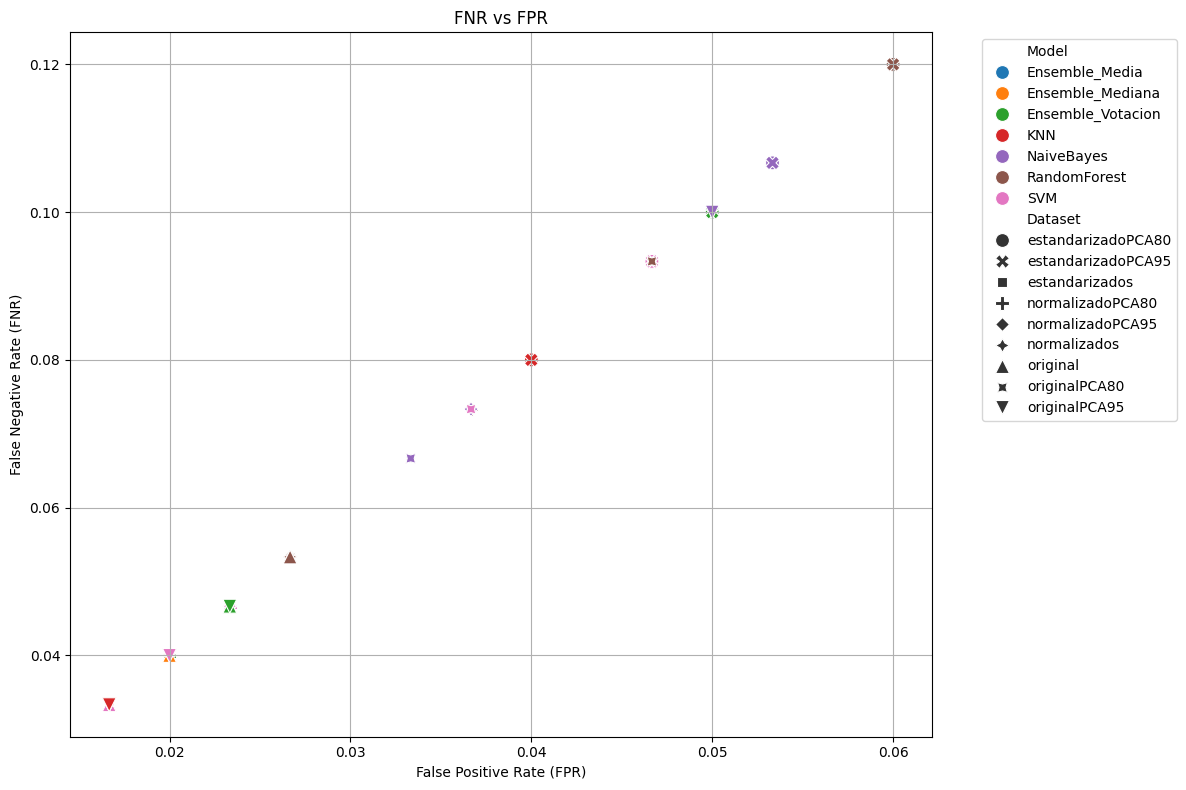

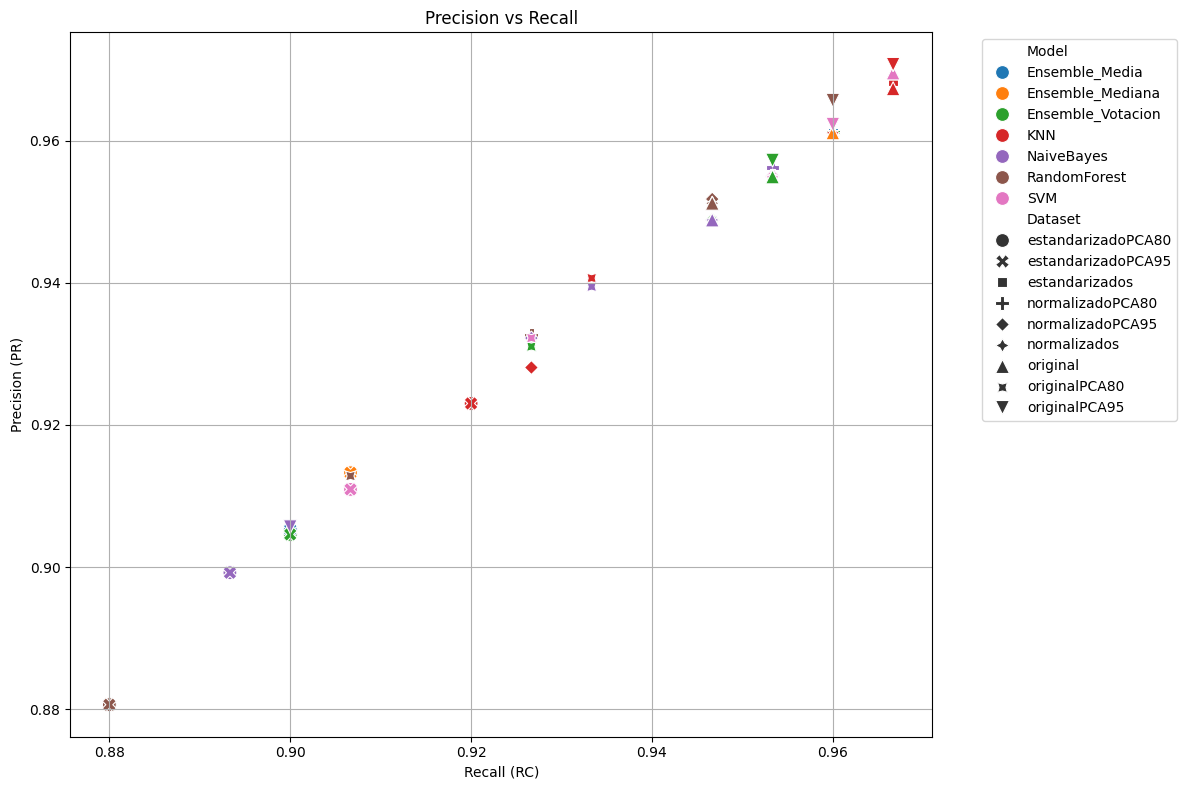

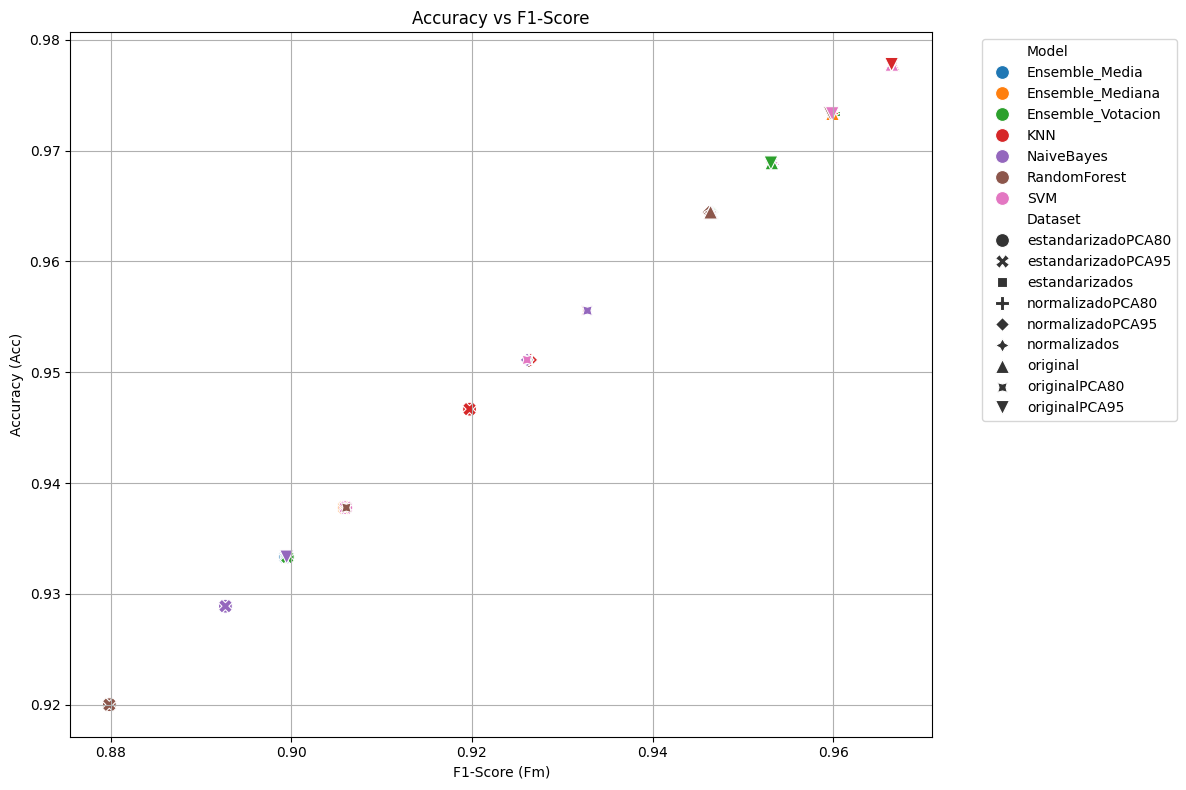

In [7]:
def plot_scatter_metrics(x_col, y_col, xlabel, ylabel, title):
    plt.figure(figsize=(12, 8))
    
    # Usamos los valores medios para el plot
    plot_data = means.reset_index()
    
    sns.scatterplot(data=plot_data, x=x_col, y=y_col, hue='Model', style='Dataset', s=100)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 1. FN contra FP 
if 'FPR' in means.columns and 'FNR' in means.columns:
    plot_scatter_metrics('FPR', 'FNR', 'False Positive Rate (FPR)', 'False Negative Rate (FNR)', 'FNR vs FPR')

# 2. PR contra RC
if 'RC' in means.columns and 'PR' in means.columns:
    plot_scatter_metrics('RC', 'PR', 'Recall (RC)', 'Precision (PR)', 'Precision vs Recall')

# 3. ACC contra Fm
if 'Fm' in means.columns and 'Acc' in means.columns:
    plot_scatter_metrics('Fm', 'Acc', 'F1-Score (Fm)', 'Accuracy (Acc)', 'Accuracy vs F1-Score')